In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load all files
train = pd.read_csv('./Data/train.csv')
center_info = pd.read_csv('./Data/fulfilment_center_info.csv')
meal_info = pd.read_csv('./Data/meal_info.csv')

In [4]:
# Quick look at each before merging
print(train.head())
print('-'*40)
print(center_info.head())
print('-'*40)
print(meal_info.head())
print('-'*40)

        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0          40  
----------------------------------------
   center_id  city_code  region_code center_type  op_area
0         11        679           56      TYPE_A      3.7
1         13        590           56      TYPE_B      6.7
2        124        590     

In [5]:
# Left Join train with center_info on center_id
df = train.merge(center_info, on='center_id', how='left')

# Left Join that with meal_info on meal_id
df = df.merge(meal_info, on='meal_id', how='left')

In [6]:
# Now Lets view the Data
print('-'*50)
print(df.shape)
print('-'*50)
print(df.head())
print('-'*50)
print(df.info())
print('-'*50)
print(df.describe())

--------------------------------------------------
(456548, 15)
--------------------------------------------------
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                      0                  0         177        647   
1                      0                  0         270        647   
2                      0                  0         189        647   
3                      0                  0          54        647   
4                      0                  0          40        647   

   region_code center_type  op_area   category cuisine 

                 id           week      center_id        meal_id  \
count  4.565480e+05  456548.000000  456548.000000  456548.000000   
mean   1.250096e+06      74.768771      82.105796    2024.337458   
std    1.443548e+05      41.524956      45.975046     547.420920   
min    1.000000e+06       1.000000      10.000000    1062.000000   
25%    1.124999e+06      39.000000      43.000000    1558.000000   
50%    1.250184e+06      76.000000      76.000000    1993.000000   
75%    1.375140e+06     111.000000     110.000000    2539.000000   
max    1.499999e+06     145.000000     186.000000    2956.000000   

       checkout_price     base_price  emailer_for_promotion  \
count   456548.000000  456548.000000          456548.000000   
mean       332.238933     354.156627               0.081152   
std        152.939723     160.715914               0.273069   
min          2.970000      55.350000               0.000000   
25%        228.950000     243.500000               0.000000   
50%      

In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df.isnull().sum())

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64


## Univariate Analysis

In [9]:
# Sanity check: checkout price should never exceed base price (that would mean a "negative discount")
print((df['checkout_price'] > df['base_price']).sum())

# This Means that we got Loss in 116101 orders

116101


In [10]:
# Sanity check: no negative prices or negative orders
print((df['checkout_price'] < 0).sum())
print((df['num_orders'] < 0).sum())

0
0


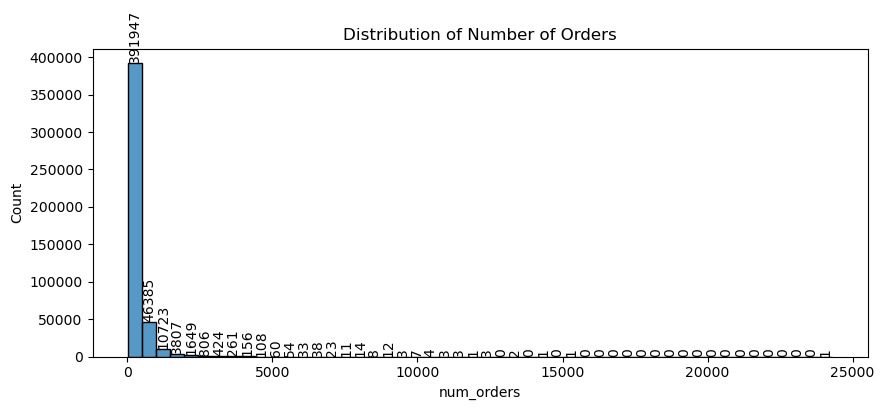

In [11]:
# Histogram - see the shape/skew
plt.figure(figsize=(10,4))
ax = sns.histplot(df['num_orders'], bins=50)
# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container,rotation=90)

plt.title('Distribution of Number of Orders')
plt.savefig('./Charts/01_num_orders_hist.png', dpi=150, bbox_inches='tight')
plt.show()

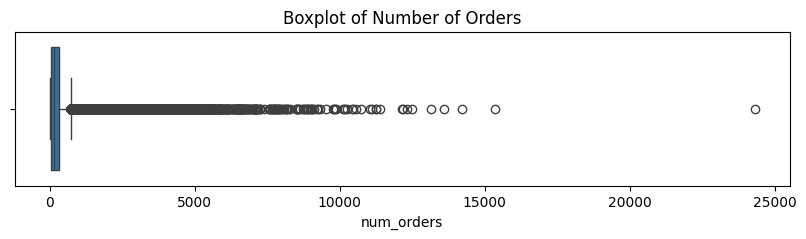

In [11]:
# Boxplot - see outliers visually
plt.figure(figsize=(10,2))
sns.boxplot(x=df['num_orders'])
plt.title('Boxplot of Number of Orders')
plt.savefig('./Charts/02_num_orders_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
Q1 = df['num_orders'].quantile(0.25)
print(Q1)

54.0


In [13]:
Q3 = df['num_orders'].quantile(0.75)
print(Q3)

324.0


In [14]:
# Here the values more than and lower than these values are considered as outlier
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower,upper)


-351.0 729.0


In [15]:
# IQR method to quantify outliers
Q1 = df['num_orders'].quantile(0.25)
Q3 = df['num_orders'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['num_orders'] < lower) | (df['num_orders'] > upper)]
print(f"Number of outliers: {len(outliers)} out of {len(df)}")
print(f"Outlier bounds: {lower} to {upper}")

Number of outliers: 32937 out of 456548
Outlier bounds: -351.0 to 729.0


In [16]:
# What do the outlier rows look like?
print(outliers['category'].value_counts().head())
print(outliers['emailer_for_promotion'].mean())  # compare to df['emailer_for_promotion'].mean()
print(outliers['homepage_featured'].mean())      # compare to df['homepage_featured'].mean()

category
Beverages    13614
Rice Bowl     8137
Sandwich      5769
Salad         2401
Pizza         1313
Name: count, dtype: int64
0.2844217749036039
0.38385402434951577


In [17]:
print(df['emailer_for_promotion'].mean())
print(df['homepage_featured'].mean())

0.08115247465764827
0.10919990888143197


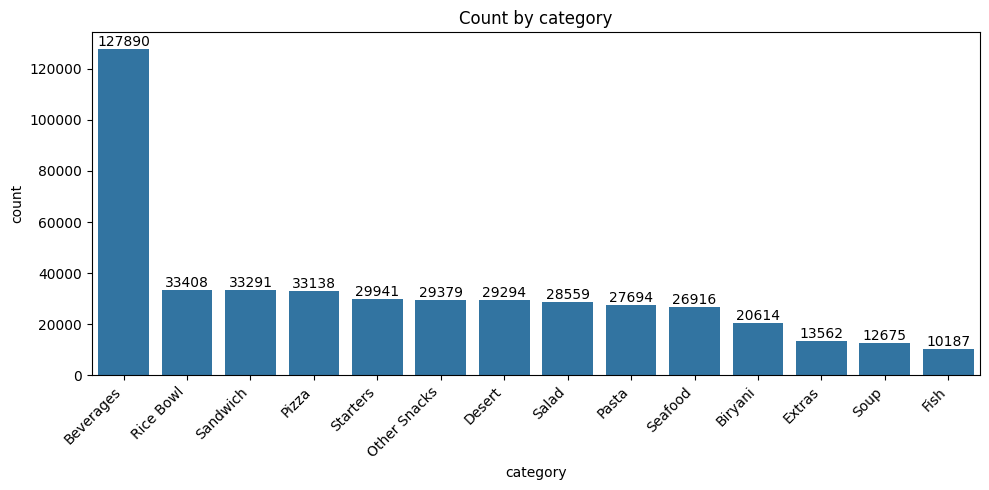

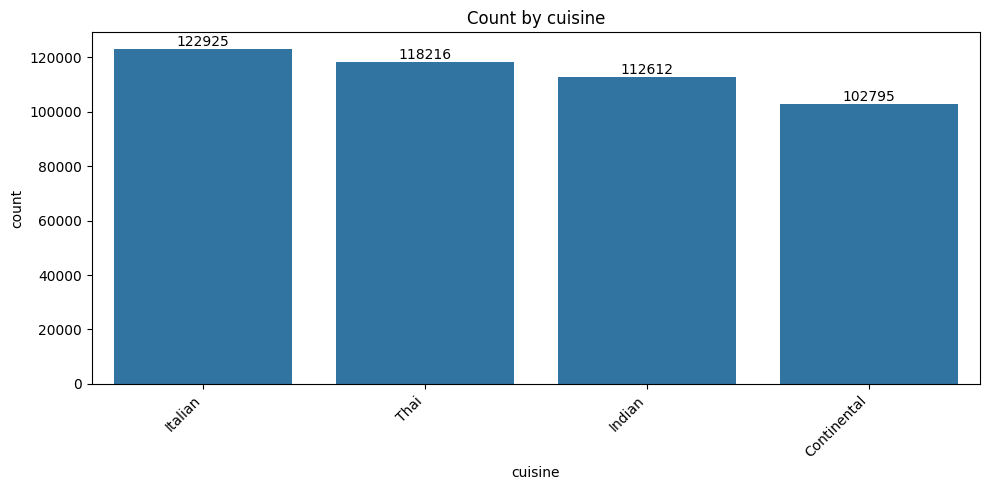

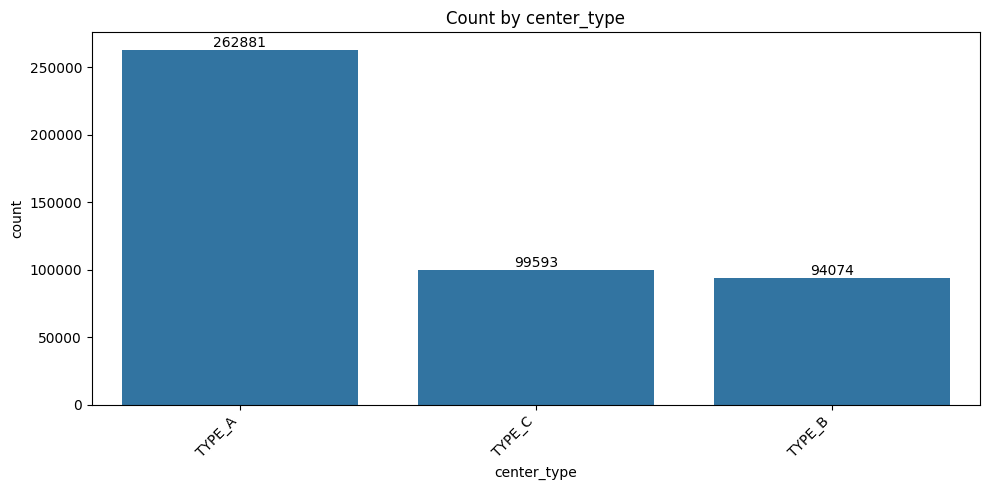

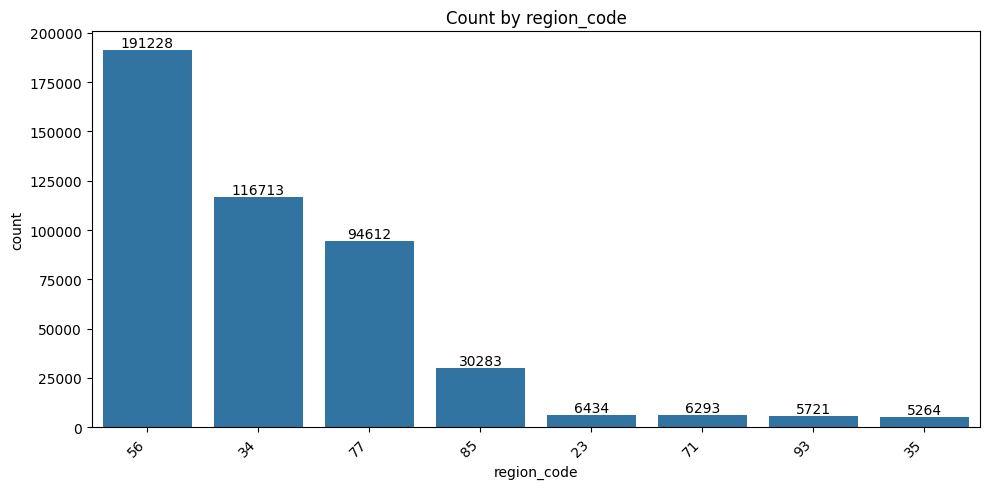

In [18]:
for col in ['category', 'cuisine', 'center_type', 'region_code']:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    for container in ax.containers:
        ax.bar_label(container)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Count by {col}')
    plt.tight_layout()
    plt.savefig(f'charts/count_by_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

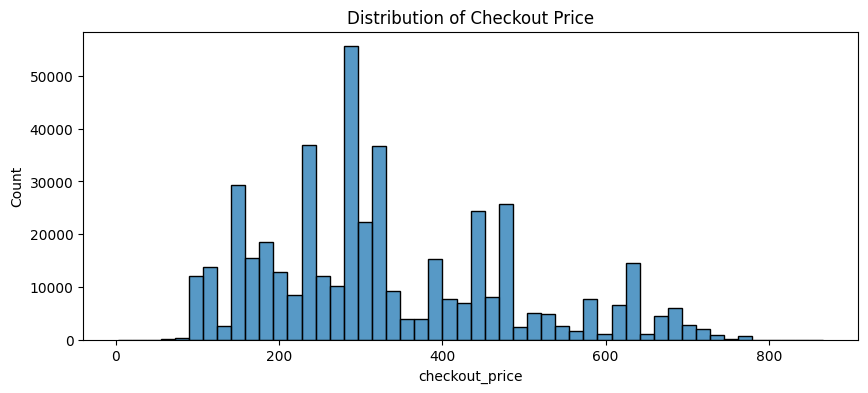

In [19]:
# Histogram - see the shape/skew
plt.figure(figsize=(10,4))
ax = sns.histplot(df['checkout_price'], bins=50)

plt.title('Distribution of Checkout Price')
plt.savefig('./Charts/07_checkoutprice_hist.png', dpi=150, bbox_inches='tight')
plt.show()

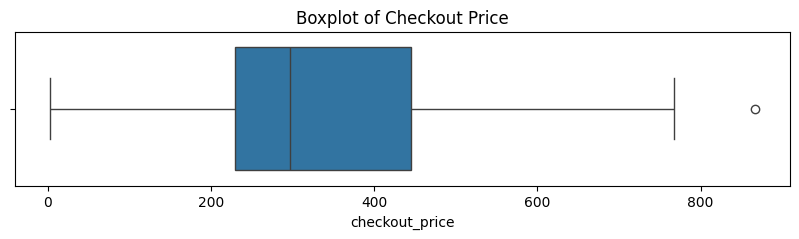

In [20]:
# Boxplot - see outliers visually
plt.figure(figsize=(10,2))
sns.boxplot(x=df['checkout_price'])
plt.title('Boxplot of Checkout Price')
plt.savefig('./Charts/08_checkoutprice_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


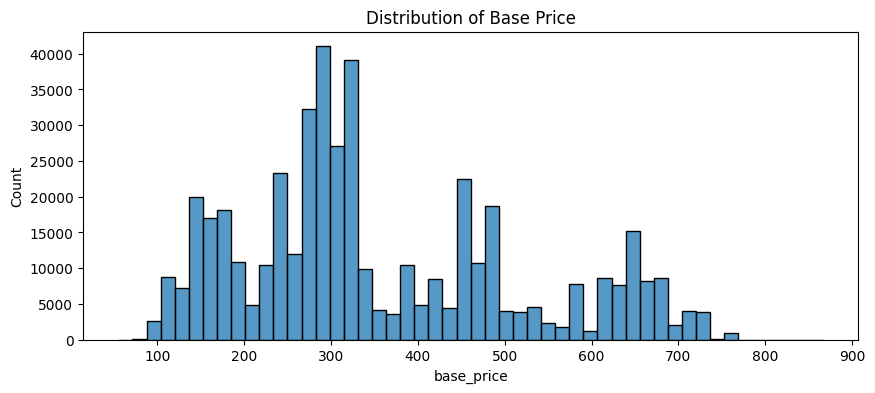

In [21]:
# Histogram - see the shape/skew
plt.figure(figsize=(10,4))
ax = sns.histplot(df['base_price'], bins=50)

plt.title('Distribution of Base Price')
plt.savefig('./Charts/09_baseprice_hist.png', dpi=150, bbox_inches='tight')
plt.show()

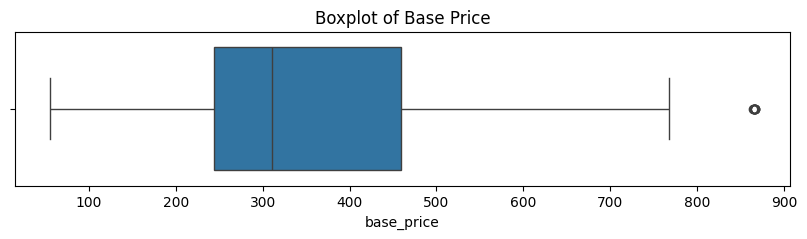

In [22]:
# Boxplot - see outliers visually
plt.figure(figsize=(10,2))
sns.boxplot(x=df['base_price'])
plt.title('Boxplot of Base Price')
plt.savefig('./Charts/10_baseprice_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Result of Univariate
- Here We got to know that 7.2% of the data flagged as Outliers
- The lower bound (-351) is meaningless here since num_orders can't be negative — so all 32,937 outliers are on the high side (orders > 729 in a week for that meal-center combo).
- Also we have noticed emailer_for_promotion or homepage_featured rates are noticeably higher in the outliers than the overall dataset average (0.081 and 0.109), that's a strong finding — "high-demand spikes are strongly associated with promotions"

In [23]:
# Compare outlier rows to the overall dataset
print("Category breakdown in outliers:")
print(outliers['category'].value_counts().head())

print("\nPromotion rate comparison:")
print(f"Overall emailer_for_promotion rate: {df['emailer_for_promotion'].mean():.3f}")
print(f"Outlier emailer_for_promotion rate: {outliers['emailer_for_promotion'].mean():.3f}")

print(f"\nOverall homepage_featured rate: {df['homepage_featured'].mean():.3f}")
print(f"Outlier homepage_featured rate: {outliers['homepage_featured'].mean():.3f}")

Category breakdown in outliers:
category
Beverages    13614
Rice Bowl     8137
Sandwich      5769
Salad         2401
Pizza         1313
Name: count, dtype: int64

Promotion rate comparison:
Overall emailer_for_promotion rate: 0.081
Outlier emailer_for_promotion rate: 0.284

Overall homepage_featured rate: 0.109
Outlier homepage_featured rate: 0.384


## Bivariate Analysis

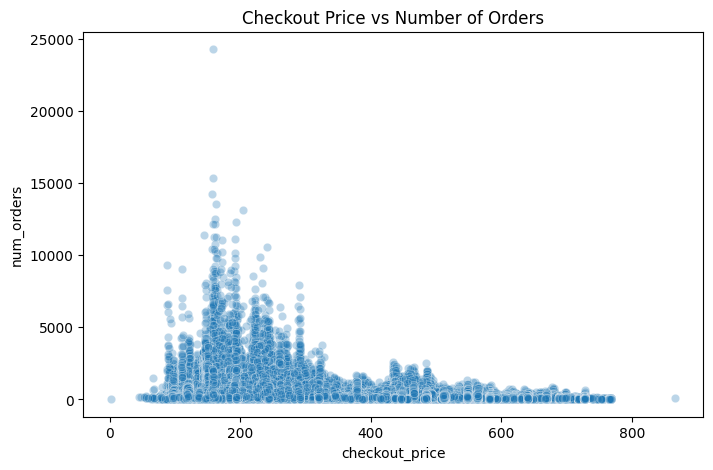

Correlation: -0.28210835168079945


In [24]:
# 1. checkout_price vs num_orders (does price affect demand?)
plt.figure(figsize=(8,5))
sns.scatterplot(x='checkout_price', y='num_orders', data=df, alpha=0.3)
plt.title('Checkout Price vs Number of Orders')
plt.savefig('./Charts/11_price_vs_orders_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation:", df['checkout_price'].corr(df['num_orders']))


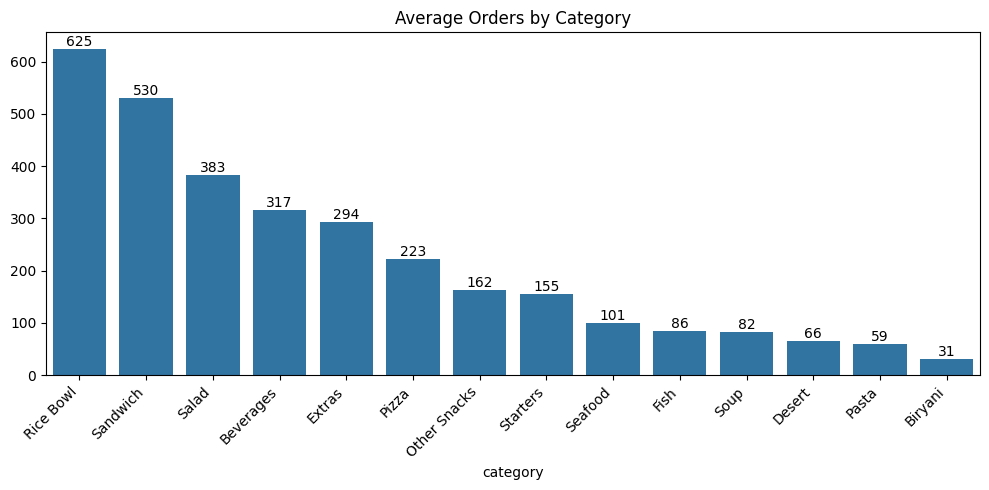

In [25]:
# 2. category vs average num_orders
plt.figure(figsize=(10,5))
avg_by_cat = df.groupby('category')['num_orders'].mean().sort_values(ascending=False)
ax = sns.barplot(x=avg_by_cat.index, y=avg_by_cat.values)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.xticks(rotation=45, ha='right')
plt.title('Average Orders by Category')
plt.tight_layout()
plt.savefig('./Charts/12_avgorders_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

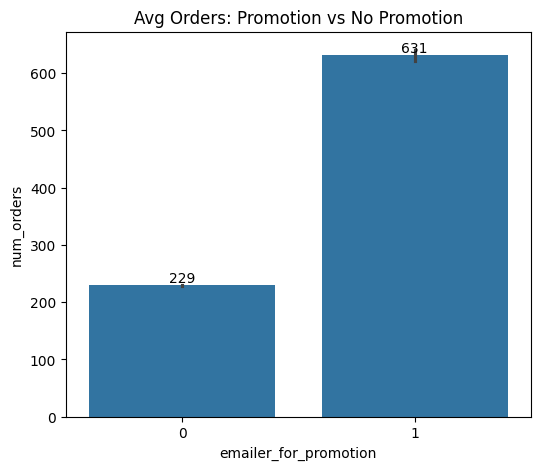

In [26]:
# 3. Does promotion actually increase orders?
plt.figure(figsize=(6,5))
ax = sns.barplot(x='emailer_for_promotion', y='num_orders', data=df)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.title('Avg Orders: Promotion vs No Promotion')
plt.savefig('./Charts/13_promo_vs_orders.png', dpi=150, bbox_inches='tight')
plt.show()

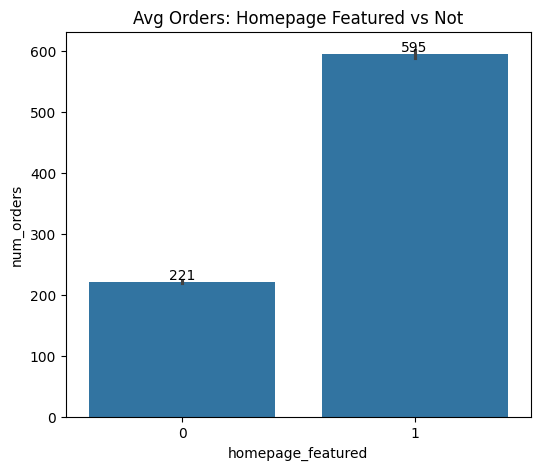

In [27]:
# 3. Does Homepage Feature increase orders?
plt.figure(figsize=(6,5))
ax = sns.barplot(x='homepage_featured', y='num_orders', data=df)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.title('Avg Orders: Homepage Featured vs Not')
plt.savefig('./Charts/14_homepage_vs_orders.png', dpi=150, bbox_inches='tight')
plt.show()

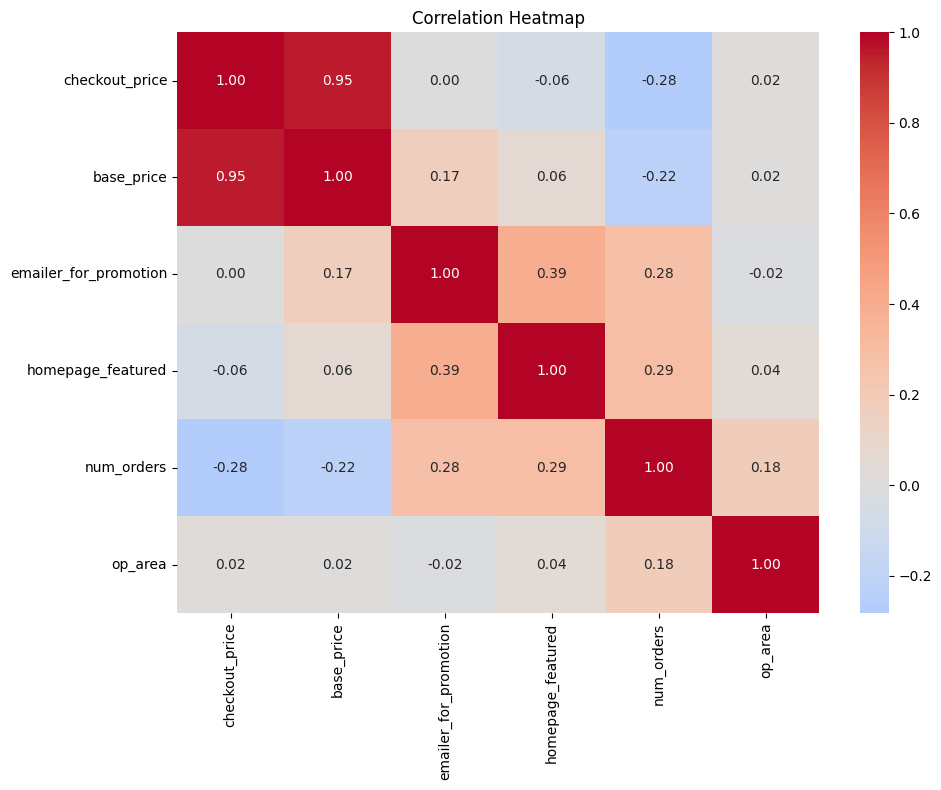

In [28]:
# 1. Correlation heatmap - see all numeric relationships at once
plt.figure(figsize=(10,8))
numeric_cols = ['checkout_price', 'base_price', 'emailer_for_promotion', 
                 'homepage_featured', 'num_orders', 'op_area']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('./Charts/15_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


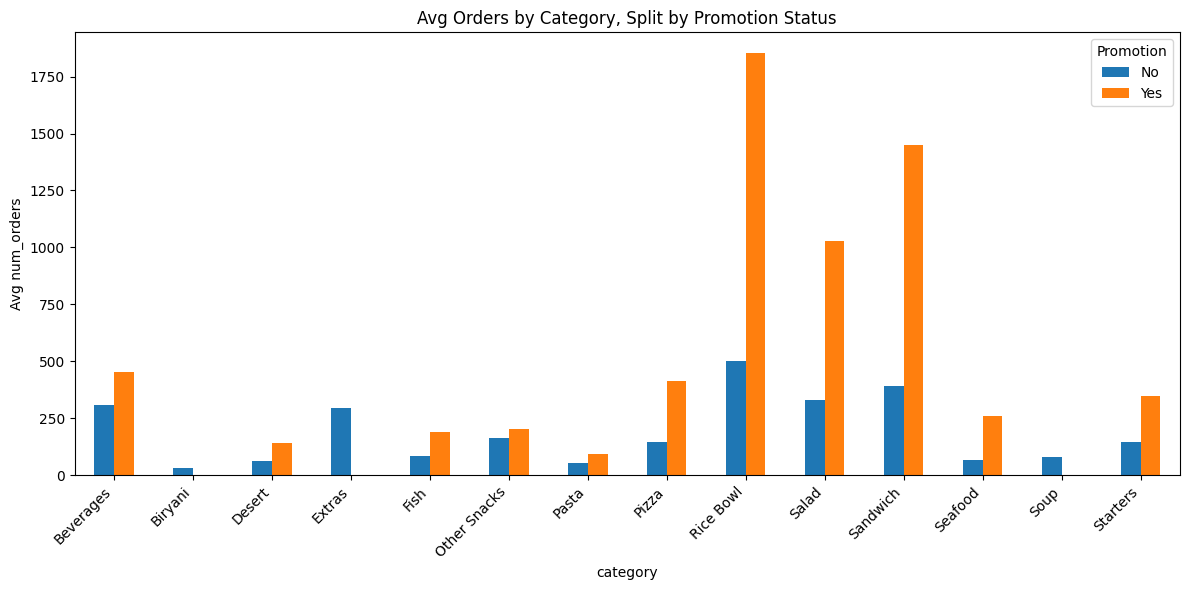

In [29]:
# 2. Does promotion effect differ by category? (3 variables: category, promotion, num_orders)
plt.figure(figsize=(12,6))
promo_by_cat = df.groupby(['category', 'emailer_for_promotion'])['num_orders'].mean().unstack()
promo_by_cat.plot(kind='bar', ax=plt.gca())
plt.title('Avg Orders by Category, Split by Promotion Status')
plt.ylabel('Avg num_orders')
plt.legend(title='Promotion', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./Charts/16_category_promo_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

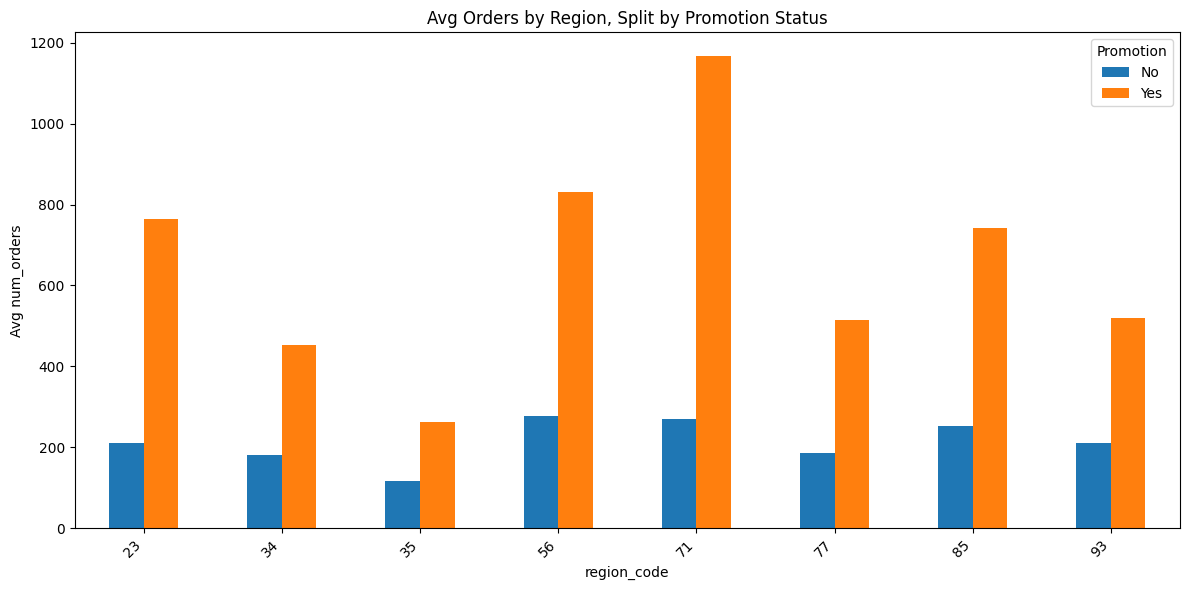

In [30]:
# 3. Does promotion effect differ by region? (3 variables: region, promotion, num_orders)
plt.figure(figsize=(12,6))
promo_by_region = df.groupby(['region_code', 'emailer_for_promotion'])['num_orders'].mean().unstack()
promo_by_region.plot(kind='bar', ax=plt.gca())
plt.title('Avg Orders by Region, Split by Promotion Status')
plt.ylabel('Avg num_orders')
plt.legend(title='Promotion', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./Charts/17_region_promo_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

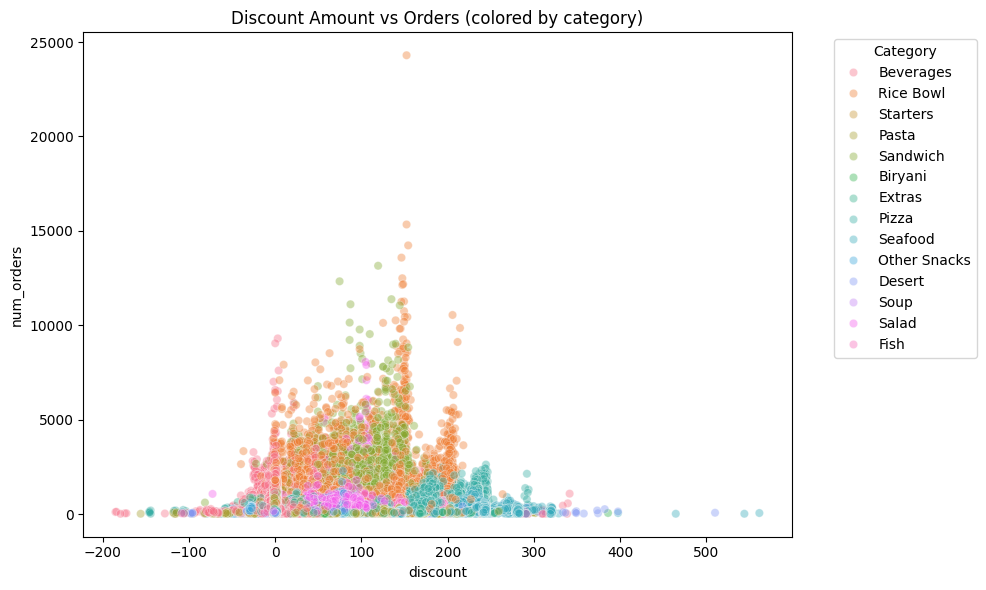

In [31]:
# 4. Discount amount vs demand, colored by category (numeric + numeric + categorical)
df['discount'] = df['base_price'] - df['checkout_price']
plt.figure(figsize=(10,6))
sns.scatterplot(x='discount', y='num_orders', hue='category', data=df, alpha=0.4)
plt.title('Discount Amount vs Orders (colored by category)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category')
plt.tight_layout()
plt.savefig('./Charts/18_discount_vs_orders_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
print((df['discount'] < 0).sum())
df[df['discount'] < 0][['category','base_price','checkout_price','discount']].head()

116101


,category,base_price,checkout_price,discount
1,Beverages,135.83,136.83,-1.0
4,Beverages,242.50,243.50,-1.0
8,Beverages,192.06,193.06,-1.0
12,Rice Bowl,310.43,311.43,-1.0
15,Starters,281.33,282.33,-1.0


In [33]:
# Confirm it's really always exactly -1.0
print(df[df['discount'] < 0]['discount'].value_counts())


discount
-1.00     73668
-2.00     36902
-0.97       330
-1.97       221
-0.03       218
          ...  
-74.66        1
-76.60        1
-35.83        1
-77.57        1
-73.66        1
Name: count, Length: 699, dtype: int64


In [34]:

# Does this pattern correlate with anything - category, center_type, specific week?
print(df[df['discount'] < 0]['category'].value_counts())
print(df[df['discount'] < 0]['center_type'].value_counts())
print(df[df['discount'] < 0]['week'].describe())

category
Beverages       34293
Starters         9087
Sandwich         8843
Rice Bowl        8260
Salad            8258
Desert           7068
Pizza            6757
Other Snacks     6651
Seafood          6374
Pasta            6031
Biryani          5876
Soup             3382
Fish             3082
Extras           2139
Name: count, dtype: int64
center_type
TYPE_A    66963
TYPE_C    24780
TYPE_B    24358
Name: count, dtype: int64
count    116101.000000
mean         75.629142
std          41.369195
min           1.000000
25%          41.000000
50%          76.000000
75%         111.000000
max         145.000000
Name: week, dtype: float64


# Week 2: Data Preprocessing

## Step 1: Re-confirm data quality (missing values & duplicates)

In [12]:
# Re-confirm missing values and duplicates before preprocessing
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total duplicate rows:", df.duplicated().sum())


Missing values per column:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

Total duplicate rows: 0


Total duplicate rows: 0


**Result:** 0 missing values and 0 duplicate rows confirmed — no imputation or de-duplication needed.

## Step 2: Handling outliers in `num_orders` (log-transform)

From EDA, `num_orders` is heavily right-skewed (skewness ≈ 6.93) with ~7.2% of rows flagged as outliers by the IQR method.
These outliers are **not data errors** — they correlate strongly with `emailer_for_promotion` and `homepage_featured`, meaning they represent genuine high-demand spikes. Since a demand-forecasting dataset should preserve real spikes, we apply a **log1p transform** rather than capping or removing rows. This compresses the scale without deleting any information (fully reversible via `np.expm1`).

In [13]:
# BEFORE: raw num_orders stats
print("BEFORE (raw num_orders):")
print(df['num_orders'].describe())
print("Skewness:", df['num_orders'].skew())


BEFORE (raw num_orders):
count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64
Skewness: 6.929966065342181


Skewness: 6.929966065342181


In [14]:
# Apply log1p transform (log(1 + x)), keep original column intact
df['num_orders_log'] = np.log1p(df['num_orders'])

print("AFTER (log1p num_orders):")
print(df['num_orders_log'].describe())
print("Skewness:", df['num_orders_log'].skew())


AFTER (log1p num_orders):
count    456548.000000
mean          4.888190
std           1.203166
min           2.639057
25%           4.007333
50%           4.919981
75%           5.783825
max          10.098232
Name: num_orders_log, dtype: float64
Skewness: -0.021917624028338238


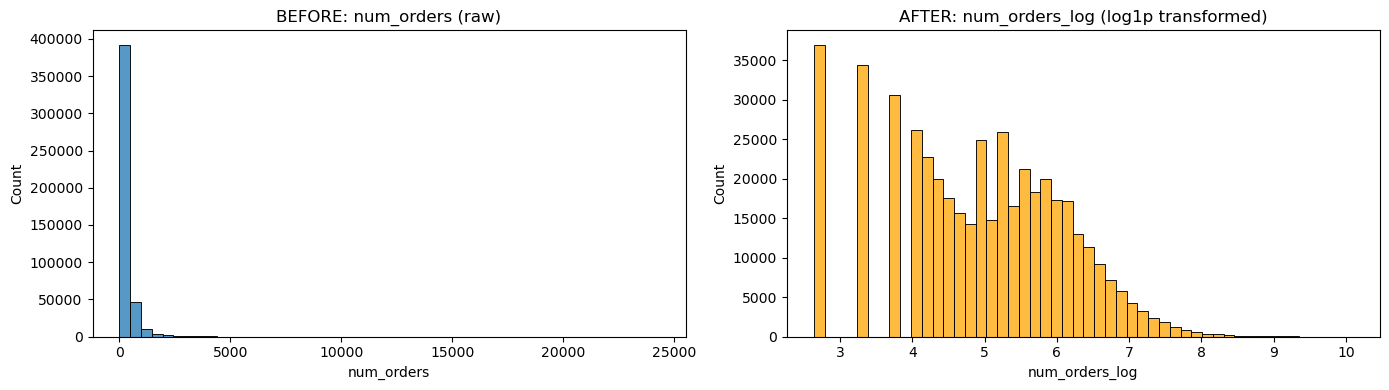

In [15]:
# Visual before/after comparison
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df['num_orders'], bins=50, ax=axes[0])
axes[0].set_title('BEFORE: num_orders (raw)')
sns.histplot(df['num_orders_log'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('AFTER: num_orders_log (log1p transformed)')
plt.tight_layout()
plt.savefig('./Charts/19_before_after_num_orders_transform.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3: Handling negative discount rows (flag, don't remove)

From EDA, ~25% of rows (116,101) have `checkout_price > base_price`, producing a negative `discount` value. Since we cannot confirm these are data-entry errors (they may reflect real surge pricing), we **keep every row** and instead add a boolean flag column so the pattern is explicit and usable as a feature, rather than silently deleting a quarter of the dataset.

In [16]:
# Recreate discount column and flag negative-discount rows instead of removing them
df['discount'] = df['base_price'] - df['checkout_price']
df['has_negative_discount'] = df['discount'] < 0

print("Rows flagged as negative discount:", df['has_negative_discount'].sum())
print("Percent of dataset:", round(df['has_negative_discount'].mean()*100, 2), "%")
print(df['has_negative_discount'].value_counts())


Rows flagged as negative discount: 116101
Percent of dataset: 25.43 %
has_negative_discount
False    340447
True     116101
Name: count, dtype: int64


## Step 4: Data transformation — scaling numeric features

`checkout_price`, `base_price`, and `op_area` are on very different numeric ranges. We apply `StandardScaler` so no single feature dominates a model purely due to scale (each scaled column will have mean ≈ 0, std ≈ 1).

In [17]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['checkout_price', 'base_price', 'op_area']

print("BEFORE scaling:")
print(df[cols_to_scale].describe().loc[['mean','std','min','max']])

scaler = StandardScaler()
scaled_vals = scaler.fit_transform(df[cols_to_scale])
scaled_df = pd.DataFrame(scaled_vals, columns=[c + '_scaled' for c in cols_to_scale])
df = pd.concat([df.reset_index(drop=True), scaled_df], axis=1)

print()
print("AFTER scaling:")
print(df[['checkout_price_scaled','base_price_scaled','op_area_scaled']].describe().loc[['mean','std','min','max']])


BEFORE scaling:
      checkout_price  base_price   op_area
mean      332.238933  354.156627  4.083590
std       152.939723  160.715914  1.091686
min         2.970000   55.350000  0.900000
max       866.270000  866.270000  7.000000

AFTER scaling:
      checkout_price_scaled  base_price_scaled  op_area_scaled
mean           4.581857e-16      -1.792901e-17    3.037971e-16
std            1.000001e+00       1.000001e+00    1.000001e+00
min           -2.152935e+00      -1.859224e+00   -2.916216e+00
max            3.491779e+00       3.186454e+00    2.671475e+00


## Step 5: Data transformation — encoding categorical features

`category` (14 values), `cuisine` (4 values), and `center_type` (3 values) are text categoricals. `region_code` is numeric but is actually a **nominal ID** (region 8 isn't "more" than region 4), so it should not be treated as an ordered number — it only has 8 unique values, so it's safe to one-hot encode as well.

In [18]:
cat_cols = ['category', 'cuisine', 'center_type', 'region_code']

print("Cardinality per categorical column:")
for c in cat_cols:
    print(f"  {c}: {df[c].nunique()} unique values")

print()
print("Shape BEFORE encoding:", df.shape)
df = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols)
print("Shape AFTER one-hot encoding:", df.shape)


Cardinality per categorical column:
  category: 14 unique values
  cuisine: 4 unique values
  center_type: 3 unique values
  region_code: 8 unique values

Shape BEFORE encoding: (456548, 21)
Shape AFTER one-hot encoding: (456548, 46)


Shape AFTER one-hot encoding: (456548, 46)


## Step 6: Data reduction — dropping redundant ID columns

`id`, `center_id`, `meal_id`, and `city_code` are row/lookup identifiers with no predictive value once used for merging and encoding — keeping them risks a model treating arbitrary ID numbers as meaningful quantities.

In [19]:
print("Shape before reduction:", df.shape)

id_cols_to_drop = ['id', 'center_id', 'meal_id', 'city_code']
df = df.drop(columns=id_cols_to_drop)

print("Shape after dropping ID columns:", df.shape)


Shape before reduction: (456548, 46)
Shape after dropping ID columns: (456548, 42)


## Step 7: Before vs after preprocessing — full summary

In [20]:
print("Final dtypes breakdown:")
print(df.dtypes.value_counts())
print()
print("Final shape:", df.shape)
print("Final columns:")
print(df.columns.tolist())


Final dtypes breakdown:
bool       30
float64     8
int64       4
Name: count, dtype: int64

Final shape: (456548, 42)
Final columns:
['week', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'op_area', 'num_orders_log', 'discount', 'has_negative_discount', 'checkout_price_scaled', 'base_price_scaled', 'op_area_scaled', 'category_Beverages', 'category_Biryani', 'category_Desert', 'category_Extras', 'category_Fish', 'category_Other Snacks', 'category_Pasta', 'category_Pizza', 'category_Rice Bowl', 'category_Salad', 'category_Sandwich', 'category_Seafood', 'category_Soup', 'category_Starters', 'cuisine_Continental', 'cuisine_Indian', 'cuisine_Italian', 'cuisine_Thai', 'center_type_TYPE_A', 'center_type_TYPE_B', 'center_type_TYPE_C', 'region_code_23', 'region_code_34', 'region_code_35', 'region_code_56', 'region_code_71', 'region_code_77', 'region_code_85', 'region_code_93']


### Summary table (for report)

| | Before | After |
|---|---|---|
| Rows | 456,548 | 456,548 (unchanged) |
| Columns | 15 | 42 |
| Missing values | 0 | 0 |
| Duplicates | 0 | 0 |
| `num_orders` skewness | 6.93 | `num_orders_log` skewness: -0.02 |
| Categorical columns | 4 raw text columns | 30 one-hot boolean columns |
| Numeric scale | Inconsistent ranges | Standardized (mean 0, std 1) |
| Negative discounts | Undocumented | Flagged via `has_negative_discount` |


## Save preprocessed dataset

In [21]:
df.to_csv('preprocessed_food_demand.csv', index=False)
print("Saved preprocessed_food_demand.csv:", df.shape)


Saved preprocessed_food_demand.csv: (456548, 42)
